In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from utils import *


In [2]:
root_dir, data_dir = get_notebook_paths()
MIMIC_CXR_JPG_DIR = data_dir / "MIMIC-CXR-JPG"
DATA_CAMCHEX = data_dir / "camchex"

print(Path.cwd())
print(root_dir)
print(data_dir)


/home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/00-examine-data
/home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/00-examine-data/../..
/home/tungnguyen/Programming/Chest-Medical-Image-Fusion-for-Multimodal-Clinical-Analysis/data/00-examine-data/../../data


['02_train.csv',
 '03_mimic_development.csv',
 '03_mimic_train.csv',
 '03_mimic_test.csv',
 '03_kaggle_test.csv',
 '03_kaggle_development.csv',
 '01_merged.csv',
 '02_test.csv',
 '03_kaggle_train.csv',
 '02_development.csv',
 '01_progress.csv']

In [3]:
train = pd.read_csv(DATA_CAMCHEX / "03_mimic_train.csv")
test = pd.read_csv(DATA_CAMCHEX / "03_mimic_test.csv")
dev = pd.read_csv(DATA_CAMCHEX / "03_mimic_development.csv")

train["split"] = "train"
test["split"] = "test"
dev["split"] = "dev"

data = pd.concat([train, test, dev], axis=0).reset_index(drop=True)
print(data.shape)
data.head()

del train, test, dev


(37162, 53)


In [4]:
LABEL_COLS = [
    "Atelectasis", "Calcification of the Aorta", "Cardiomegaly", "Consolidation",
    "Edema", "Emphysema", "Enlarged Cardiomediastinum", "Fibrosis", "Fracture",
    "Hernia", "Infiltration", "Lung Lesion", "Lung Opacity", "Mass", "No Finding",
    "Nodule", "Pleural Effusion", "Pleural Other", "Pleural Thickening",
    "Pneumomediastinum", "Pneumonia", "Pneumoperitoneum", "Pneumothorax",
    "Subcutaneous Emphysema", "Support Devices", "Tortuous Aorta",
]

VITAL_COLS = ["temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp"]


In [5]:
# Split summary

split_summary = (
    data.groupby("split")
    .agg(
        rows=("dicom_id", "count"),
        patients=("subject_id", "nunique"),
        studies=("study_id", "nunique"),
        images=("dicom_id", "nunique"),
    )
    .reset_index()
)

split_summary


,split,rows,patients,studies,images
0,dev,3875,651,2360,3875
1,test,7042,1245,4122,7042
2,train,26245,4628,15928,26245


In [6]:
# Check patient overlap

patients = {
    split: set(data.loc[data["split"] == split, "subject_id"])
    for split in ["train", "val", "test"]
}

for a in ["train", "val", "test"]:
    for b in ["train", "val", "test"]:
        if a < b:
            overlap = patients[a] & patients[b]
            print(a, b, len(overlap))


train val 0
test train 0
test val 0


In [7]:
# Lablel distribution

label_prev = []

for split, df in data.groupby("split"):
    for label in LABEL_COLS:
        n_pos = df[label].sum()
        n_total = len(df)
        label_prev.append({
            "split": split,
            "label": label,
            "positive": int(n_pos),
            "total": int(n_total),
            "prevalence": n_pos / n_total,
        })

label_prev = pd.DataFrame(label_prev)

label_prev.sort_values(["split", "prevalence"], ascending=[True, False])


,split,label,positive,total,prevalence
24,dev,Support Devices,1386,3875,0.357677
2,dev,Cardiomegaly,1198,3875,0.309161
12,dev,Lung Opacity,1139,3875,0.293935
16,dev,Pleural Effusion,1032,3875,0.266323
0,dev,Atelectasis,999,3875,0.257806
...,...,...,...,...,...
75,train,Subcutaneous Emphysema,215,26245,0.008192
59,train,Fibrosis,141,26245,0.005372
71,train,Pneumomediastinum,70,26245,0.002667
69,train,Pleural Other,59,26245,0.002248


                     label  positive  total  prevalence
           Support Devices      8919  26245    0.339836
              Lung Opacity      7866  26245    0.299714
              Cardiomegaly      7555  26245    0.287864
          Pleural Effusion      6813  26245    0.259592
               Atelectasis      6666  26245    0.253991
                 Pneumonia      4666  26245    0.177786
                No Finding      4293  26245    0.163574
                     Edema      3705  26245    0.141170
Enlarged Cardiomediastinum      2912  26245    0.110954
             Consolidation      1523  26245    0.058030
              Pneumothorax      1381  26245    0.052620
                  Fracture      1135  26245    0.043246
              Infiltration       978  26245    0.037264
                    Nodule       769  26245    0.029301
                    Hernia       511  26245    0.019470
Calcification of the Aorta       505  26245    0.019242
                 Emphysema       484  26245    0

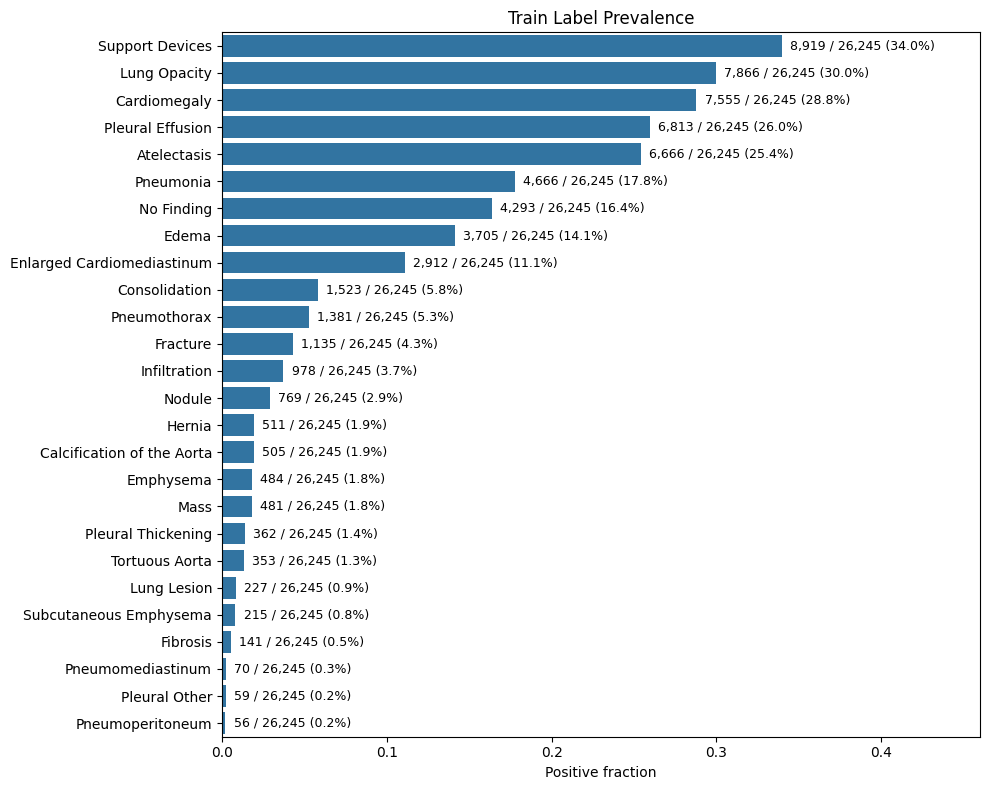

In [8]:
# Plot label imbalance

train_prev = (
    label_prev[label_prev["split"] == "train"]
    .sort_values("prevalence", ascending=False)
    .reset_index(drop=True)
)

# Print counts
print(train_prev[["label", "positive", "total", "prevalence"]].to_string(index=False))

# Plot prevalence with counts
plt.figure(figsize=(10, 8))
ax = sns.barplot(data=train_prev, x="prevalence", y="label")

plt.title("Train Label Prevalence")
plt.xlabel("Positive fraction")
plt.ylabel("")

for i, row in train_prev.iterrows():
    ax.text(
        row["prevalence"] + 0.005,
        i,
        f'{int(row["positive"]):,} / {int(row["total"]):,} ({row["prevalence"]:.1%})',
        va="center",
        fontsize=9,
    )

ax.set_xlim(0, min(1.0, train_prev["prevalence"].max() + 0.12))

plt.tight_layout()
plt.show()


In [9]:
# Check missing

cols_to_check = [
    "clinical_indication",
    "temperature", "heartrate", "resprate", "o2sat", "sbp", "dbp",
    "gender", "ViewPosition", "path",
]

missing = []

for split, df in data.groupby("split"):
    for col in cols_to_check:
        missing.append({
            "split": split,
            "column": col,
            "missing": df[col].isna().sum(),
            "total": len(df),
            "missing_rate": df[col].isna().mean(),
        })

missing = pd.DataFrame(missing)
missing.sort_values(["split", "missing_rate"], ascending=[True, False])


,split,column,missing,total,missing_rate
1,dev,temperature,642,3875,0.165677
6,dev,dbp,562,3875,0.145032
4,dev,o2sat,559,3875,0.144258
5,dev,sbp,557,3875,0.143742
3,dev,resprate,554,3875,0.142968
2,dev,heartrate,528,3875,0.136258
7,dev,gender,210,3875,0.054194
8,dev,ViewPosition,143,3875,0.036903
0,dev,clinical_indication,68,3875,0.017548
9,dev,path,0,3875,0.000000


In [10]:
# View distribution

view_dist = (
    data.groupby(["split", "ViewPosition"])
    .size()
    .reset_index(name="count")
    .sort_values(["split", "count"], ascending=[True, False])
)

view_dist


,split,ViewPosition,count
0,dev,AP,1550
3,dev,PA,998
1,dev,LATERAL,827
2,dev,LL,357
4,test,AP,2536
7,test,PA,1909
5,test,LATERAL,1596
6,test,LL,711
8,train,AP,10335
12,train,PA,6621


In [11]:
# Label re appearance

label_matrix = data[LABEL_COLS].astype(int)

cooccurrence = label_matrix.T @ label_matrix
cooccurrence


,Atelectasis,Calcification of the Aorta,Cardiomegaly,Consolidation,Edema,Emphysema,Enlarged Cardiomediastinum,Fibrosis,Fracture,Hernia,...,Pleural Effusion,Pleural Other,Pleural Thickening,Pneumomediastinum,Pneumonia,Pneumoperitoneum,Pneumothorax,Subcutaneous Emphysema,Support Devices,Tortuous Aorta
Atelectasis,9645,188,3458,641,1744,157,1086,33,392,226,...,4585,17,148,31,1629,31,679,136,4512,122
Calcification of the Aorta,188,678,272,36,137,26,95,1,36,18,...,164,1,3,0,110,2,11,0,185,13
Cardiomegaly,3458,272,10509,768,2790,174,1086,54,425,237,...,3783,20,125,24,1919,14,420,51,4295,274
Consolidation,641,36,768,2193,533,49,231,9,76,31,...,1175,1,19,2,745,7,111,13,1011,11
Edema,1744,137,2790,533,5365,120,521,40,145,92,...,2794,4,34,3,1064,10,166,22,2500,50
Emphysema,157,26,174,49,120,652,96,21,24,30,...,214,7,11,7,145,0,69,10,174,13
Enlarged Cardiomediastinum,1086,95,1086,231,521,96,4126,34,165,96,...,1016,18,56,105,739,14,228,81,1296,73
Fibrosis,33,1,54,9,40,21,34,195,7,3,...,36,0,11,1,50,0,12,1,58,3
Fracture,392,36,425,76,145,24,165,7,1540,47,...,353,5,39,5,184,0,162,45,496,37
Hernia,226,18,237,31,92,30,96,3,47,700,...,192,3,1,8,138,6,29,4,232,3


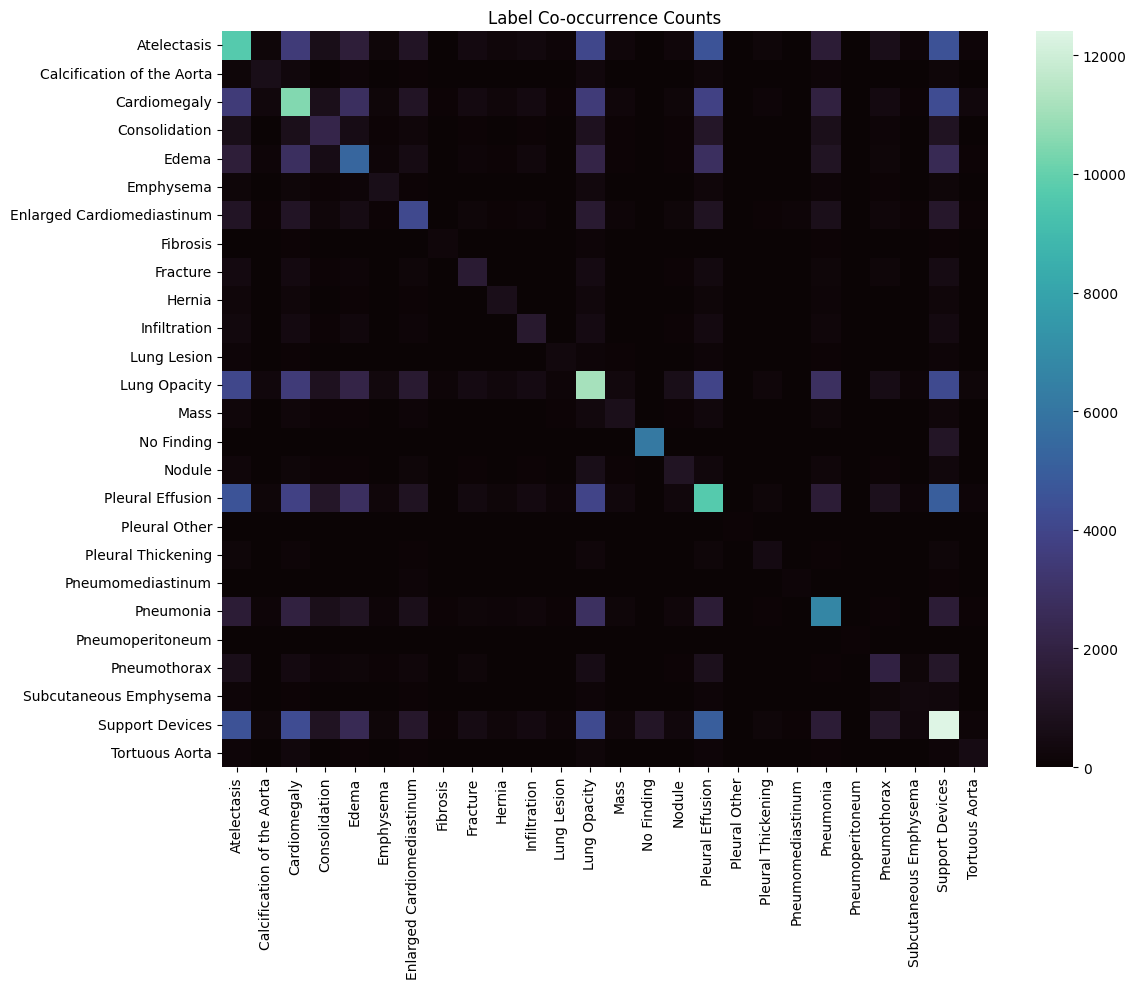

In [12]:
plt.figure(figsize=(12, 10))
sns.heatmap(cooccurrence, cmap="mako")
plt.title("Label Co-occurrence Counts")
plt.tight_layout()
plt.show()


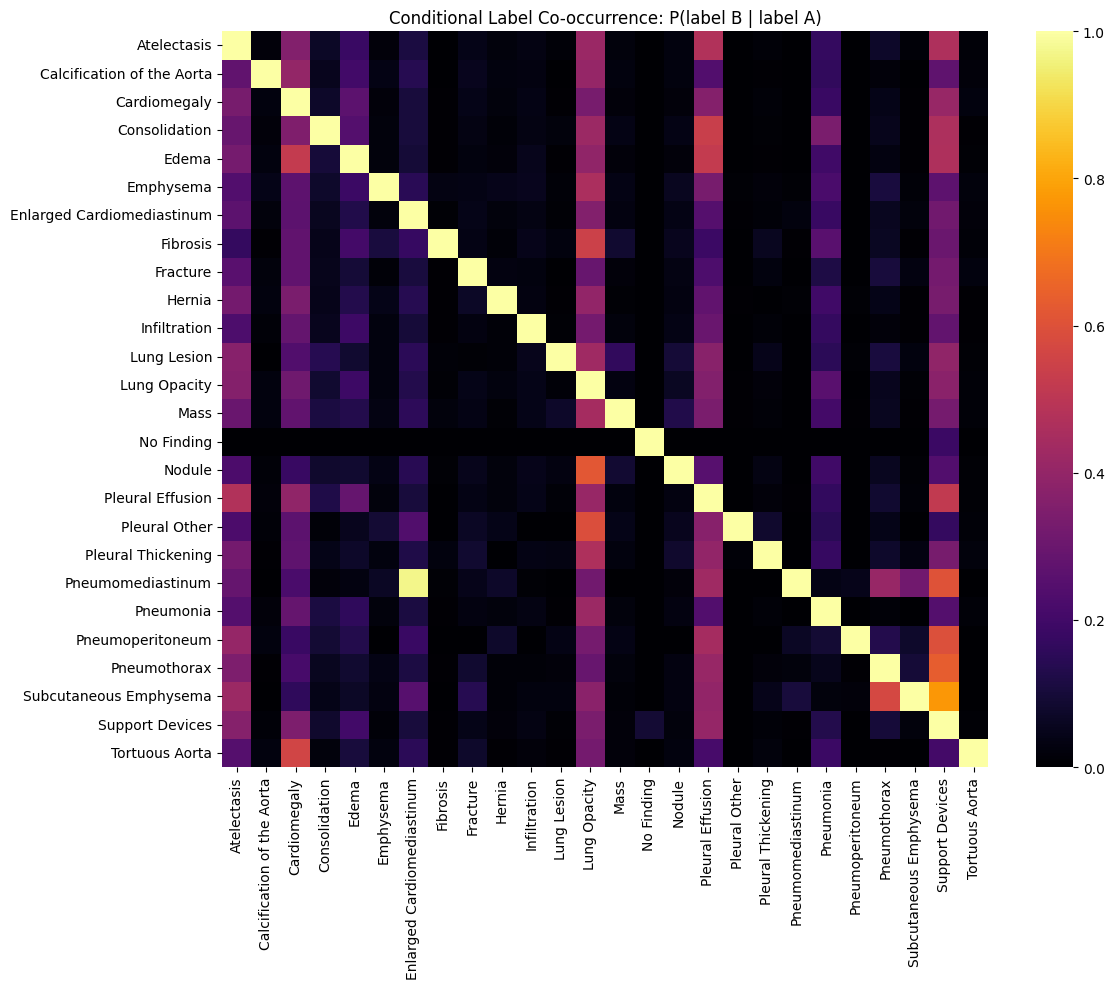

In [13]:
# Conditional co-occurrence

conditional = cooccurrence.div(np.diag(cooccurrence), axis=0)

plt.figure(figsize=(12, 10))
sns.heatmap(conditional, cmap="inferno", vmin=0, vmax=1)
plt.title("Conditional Label Co-occurrence: P(label B | label A)")
plt.tight_layout()
plt.show()


In [14]:
# Vital by disease label

vital_summary = []

for label in LABEL_COLS:
    pos = data[data[label] == 1]
    neg = data[data[label] == 0]

    for vital in VITAL_COLS:
        vital_summary.append({
            "label": label,
            "vital": vital,
            "positive_mean": pos[vital].mean(),
            "negative_mean": neg[vital].mean(),
            "difference": pos[vital].mean() - neg[vital].mean(),
            "positive_n": pos[vital].notna().sum(),
            "negative_n": neg[vital].notna().sum(),
        })

vital_summary = pd.DataFrame(vital_summary)

vital_summary.sort_values("difference", key=abs, ascending=False).head(30)


,label,vital,positive_mean,negative_mean,difference,positive_n,negative_n
59,Hernia,dbp,292.844691,77.101472,215.743219,631,31595
47,Fibrosis,dbp,70.149701,81.384042,-11.234341,167,32059
149,Support Devices,dbp,88.313221,78.274620,10.038601,9795,22431
11,Calcification of the Aorta,dbp,71.990115,81.505044,-9.514929,607,31619
143,Subcutaneous Emphysema,dbp,72.016194,81.397730,-9.381535,247,31979
113,Pleural Thickening,dbp,72.504762,81.442306,-8.937545,420,31806
77,Lung Opacity,dbp,75.026866,83.926433,-8.899566,9417,22809
35,Emphysema,dbp,72.722807,81.480730,-8.757923,570,31656
41,Enlarged Cardiomediastinum,dbp,88.510466,80.427085,8.083381,3583,28643
131,Pneumoperitoneum,dbp,73.317460,81.341510,-8.024050,63,32163


In [15]:
# Report / Text length

data["clinical_indication_words"] = (
    data["clinical_indication"]
    .fillna("")
    .astype(str)
    .str.split()
    .str.len()
)

text_summary = (
    data.groupby("split")["clinical_indication_words"]
    .describe()
)

text_summary


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,3875.0,12.402839,10.057786,0.0,7.0,10.0,15.0,137.0
test,7042.0,12.306021,11.570213,0.0,7.0,10.0,15.0,233.0
train,26245.0,12.291065,10.063833,0.0,7.0,10.0,15.0,178.0


In [16]:
# Multilable density

data["num_positive_labels"] = data[LABEL_COLS].sum(axis=1)

data.groupby("split")["num_positive_labels"].describe()


,count,mean,std,min,25%,50%,75%,max
split,,,,,,,,
dev,3875.0,2.435613,1.510818,0.0,1.0,2.0,3.0,8.0
test,7042.0,2.346634,1.480300,0.0,1.0,2.0,3.0,8.0
train,26245.0,2.386931,1.494283,0.0,1.0,2.0,3.0,9.0


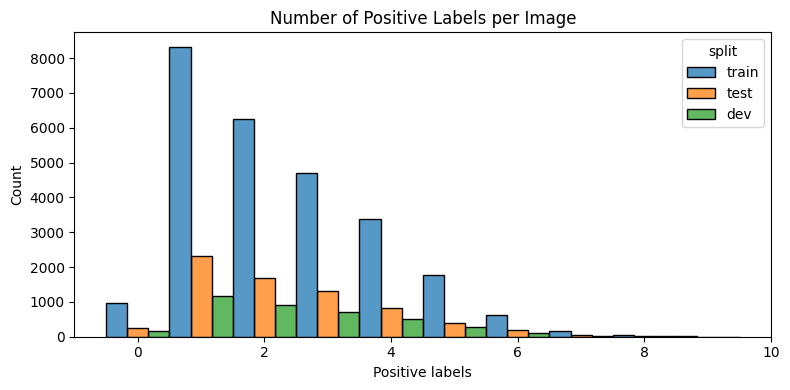

In [17]:
plt.figure(figsize=(8, 4))
sns.histplot(data=data, x="num_positive_labels", hue="split", discrete=True, multiple="dodge")
plt.title("Number of Positive Labels per Image")
plt.xlabel("Positive labels")
plt.tight_layout()
plt.show()
